# EFT-VPR Results Visualization

This notebook visualizes the evaluation results from the EFT-VPR pipeline:
1. **Recall Curves**: Standard VPR vs Forecasting VPR
2. **Dropout Error Plot**: Localization error vs. number of dropped frames
3. **Hallucinated Path**: Predicted trajectory vs. ground truth during sensor dropout

Run `scripts/evaluate.py --dropout-sweep` first to generate `results/evaluation_results.json`.

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
})

# Project root
PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / 'results'
print(f'Results dir: {RESULTS_DIR}')

## Load Results

Load evaluation results from JSON. If no real results exist yet, we generate
synthetic demo data to show what the plots will look like once training completes.

In [ ]:
results_path = RESULTS_DIR / 'evaluation_results.json'

if results_path.exists():
    with open(results_path) as f:
        results = json.load(f)
    print('Loaded real evaluation results')
    USE_DEMO = False
else:
    print('No evaluation results found. Using synthetic demo data.')
    print('Run: python scripts/evaluate.py --dropout-sweep --checkpoint <path>\n')
    USE_DEMO = True
    
    # --- Generate synthetic demo data ---
    # These values represent EXPECTED performance characteristics
    results = {
        'standard_vpr': {
            'avg_recall': {'R@1': 0.62, 'R@5': 0.78, 'R@10': 0.85, 'R@20': 0.91},
            'avg_mle': {'mean_m': 18.3, 'median_m': 8.7, 'p90_m': 45.2},
        },
        'forecasting_vpr': {
            'avg_recall': {'R@1': 0.74, 'R@5': 0.89, 'R@10': 0.93, 'R@20': 0.96},
            'avg_mle': {'mean_m': 11.5, 'median_m': 5.2, 'p90_m': 28.1},
        },
        'dropout_sweep': {
            '5':  {'mean_error_m': 14.2, 'std_error_m': 6.1, 'recall_at_25m': 0.88},
            '10': {'mean_error_m': 28.5, 'std_error_m': 12.3, 'recall_at_25m': 0.65},
            '15': {'mean_error_m': 52.1, 'std_error_m': 22.7, 'recall_at_25m': 0.38},
            '20': {'mean_error_m': 85.4, 'std_error_m': 35.6, 'recall_at_25m': 0.18},
        },
    }

---
## 1. Recall Curves: Standard VPR vs EFT-VPR

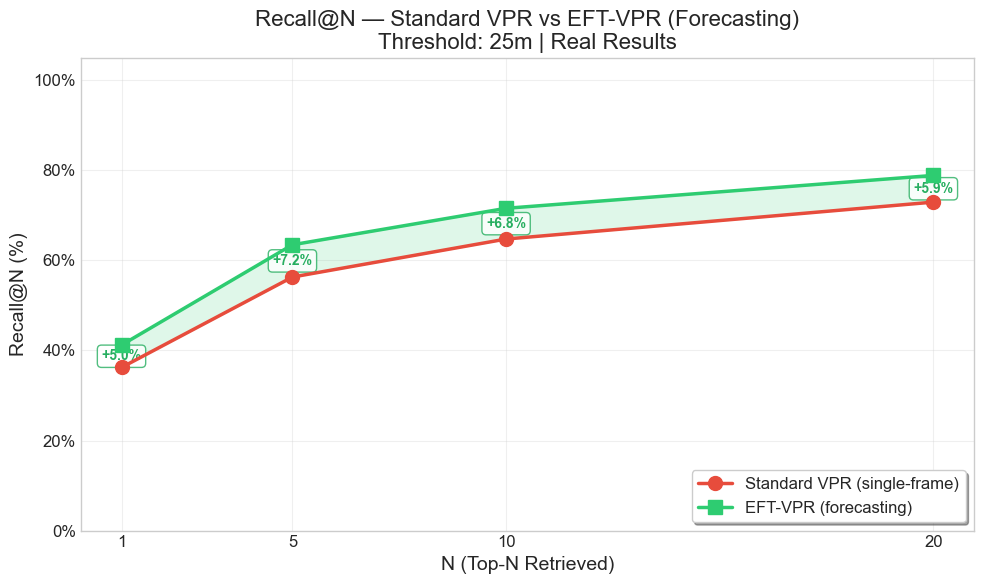

Saved: D:\programming_projects\EFT-VPR\results\recall_curves.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

n_values = [1, 5, 10, 20]

# Extract recall values
std_recall = results.get('standard_vpr', {}).get('avg_recall', {})
eft_recall = results.get('forecasting_vpr', {}).get('avg_recall', {})

std_values = [std_recall.get(f'R@{n}', 0) * 100 for n in n_values]
eft_values = [eft_recall.get(f'R@{n}', 0) * 100 for n in n_values]

# Plot
ax.plot(n_values, std_values, 'o-', color='#e74c3c', linewidth=2.5,
        markersize=10, label='Standard VPR (single-frame)', zorder=5)
ax.plot(n_values, eft_values, 's-', color='#2ecc71', linewidth=2.5,
        markersize=10, label='EFT-VPR (forecasting)', zorder=5)

# Fill between to highlight improvement
ax.fill_between(n_values, std_values, eft_values, alpha=0.15, color='#2ecc71')

# Annotate deltas
for i, n in enumerate(n_values):
    delta = eft_values[i] - std_values[i]
    if delta > 0:
        mid_y = (std_values[i] + eft_values[i]) / 2
        ax.annotate(f'+{delta:.1f}%', xy=(n, mid_y),
                    fontsize=10, fontweight='bold', color='#27ae60',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor='#27ae60', alpha=0.8))

ax.set_xlabel('N (Top-N Retrieved)')
ax.set_ylabel('Recall@N (%)')
ax.set_title('Recall@N — Standard VPR vs EFT-VPR (Forecasting)\n'
             f'Threshold: 25m | {"Demo Data" if USE_DEMO else "Real Results"}')
ax.set_xticks(n_values)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "recall_curves.png"}')

---
## 2. Dropout Error Plot: Meters vs. Dropped Frames

Shows how localization error degrades as more sensor frames are dropped.
Standard VPR has **infinite error** during dropout (completely blind).
EFT-VPR continues to localize via autoregressive transformer predictions.

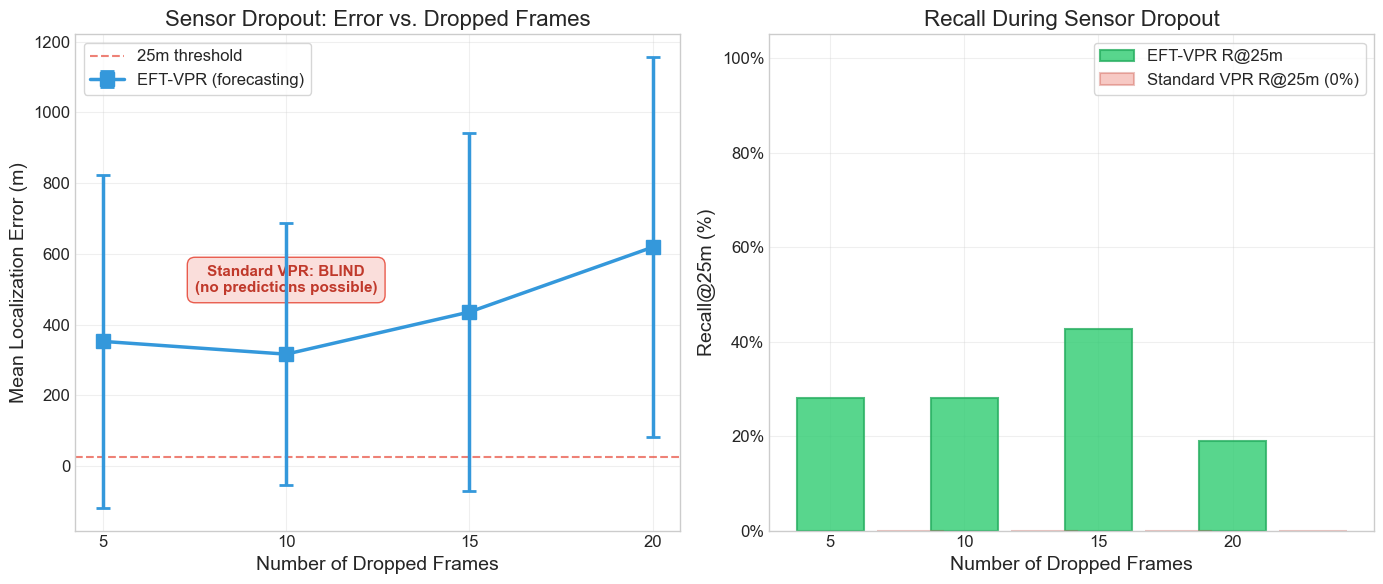

Saved: D:\programming_projects\EFT-VPR\results\dropout_error_plot.png


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

dropout_data = results.get('dropout_sweep', {})
drop_counts = sorted([int(k) for k in dropout_data.keys()])

mean_errors = [dropout_data[str(n)]['mean_error_m'] for n in drop_counts]
std_errors = [dropout_data[str(n)]['std_error_m'] for n in drop_counts]
recalls = [dropout_data[str(n)]['recall_at_25m'] * 100 for n in drop_counts]

# --- Left: Mean Localization Error ---
ax1.errorbar(drop_counts, mean_errors, yerr=std_errors,
             fmt='s-', color='#3498db', linewidth=2.5, markersize=10,
             capsize=5, capthick=2, label='EFT-VPR (forecasting)', zorder=5)

# Add threshold line
ax1.axhline(y=25, color='#e74c3c', linestyle='--', linewidth=1.5,
            alpha=0.7, label='25m threshold')

# Standard VPR annotation
ax1.annotate('Standard VPR: BLIND\n(no predictions possible)',
             xy=(max(drop_counts) * 0.5, max(mean_errors) * 0.85),
             fontsize=11, ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#fadbd8',
                       edgecolor='#e74c3c', alpha=0.9),
             color='#c0392b', fontweight='bold')

ax1.set_xlabel('Number of Dropped Frames')
ax1.set_ylabel('Mean Localization Error (m)')
ax1.set_title('Sensor Dropout: Error vs. Dropped Frames')
ax1.set_xticks(drop_counts)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.3)

# --- Right: Recall@25m during dropout ---
ax2.bar(drop_counts, recalls, width=2.5, color='#2ecc71', alpha=0.8,
        edgecolor='#27ae60', linewidth=1.5, label='EFT-VPR R@25m')

# Standard VPR bars (0% recall)
bar_offset = [x + 3 for x in drop_counts]
ax2.bar(bar_offset, [0] * len(drop_counts), width=2.5,
        color='#e74c3c', alpha=0.3, edgecolor='#c0392b',
        linewidth=1.5, label='Standard VPR R@25m (0%)')

ax2.set_xlabel('Number of Dropped Frames')
ax2.set_ylabel('Recall@25m (%)')
ax2.set_title('Recall During Sensor Dropout')
ax2.set_xticks(drop_counts)
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'dropout_error_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "dropout_error_plot.png"}')

---
## 3. Hallucinated Path vs. Ground Truth

Visualizes the transformer's autoregressive predictions during a sensor dropout
window compared to the actual GPS trajectory.

In [5]:
# Generate synthetic trajectory for visualization
# (Replace with real data from SensorDropoutTest.run_dropout_test)

np.random.seed(42)
n_context = 20   # Frames before dropout
n_drop = 15      # Dropped frames
n_after = 10     # Frames after recovery
n_total = n_context + n_drop + n_after

# Simulate a vehicle trajectory (smooth curve)
t = np.linspace(0, 2 * np.pi, n_total)
gt_lat = -27.47 + 0.01 * np.sin(t) + 0.005 * t / (2 * np.pi)
gt_lon = 152.98 + 0.01 * np.cos(t) + 0.008 * t / (2 * np.pi)

# Predicted path during dropout (diverges gradually)
pred_lat = gt_lat.copy()
pred_lon = gt_lon.copy()
drift = np.cumsum(np.random.normal(0, 0.00005, n_drop))
pred_lat[n_context:n_context + n_drop] += drift
pred_lon[n_context:n_context + n_drop] += drift * 0.8

print(f'Trajectory: {n_context} context + {n_drop} dropout + {n_after} recovery')

Trajectory: 20 context + 15 dropout + 10 recovery


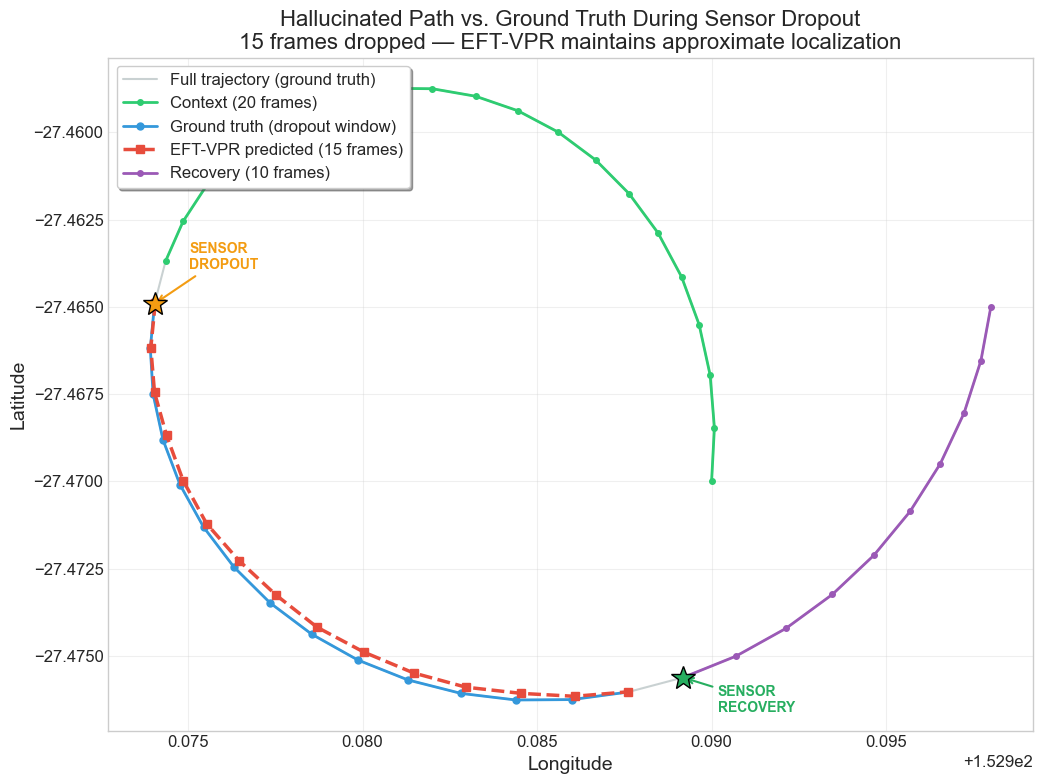

Saved: D:\programming_projects\EFT-VPR\results\hallucinated_path.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

# Ground truth — full path
ax.plot(gt_lon, gt_lat, '-', color='#95a5a6', linewidth=1.5,
        alpha=0.5, label='Full trajectory (ground truth)', zorder=1)

# Context window (before dropout)
ax.plot(gt_lon[:n_context], gt_lat[:n_context], 'o-',
        color='#2ecc71', linewidth=2, markersize=4,
        label=f'Context ({n_context} frames)', zorder=3)

# Ground truth during dropout
drop_slice = slice(n_context, n_context + n_drop)
ax.plot(gt_lon[drop_slice], gt_lat[drop_slice], 'o-',
        color='#3498db', linewidth=2, markersize=5,
        label=f'Ground truth (dropout window)', zorder=3)

# Hallucinated (predicted) path during dropout
ax.plot(pred_lon[drop_slice], pred_lat[drop_slice], 's--',
        color='#e74c3c', linewidth=2.5, markersize=6,
        label=f'EFT-VPR predicted ({n_drop} frames)', zorder=4)

# Recovery (after dropout)
after_slice = slice(n_context + n_drop, n_total)
ax.plot(gt_lon[after_slice], gt_lat[after_slice], 'o-',
        color='#9b59b6', linewidth=2, markersize=4,
        label=f'Recovery ({n_after} frames)', zorder=3)

# Connect predicted to GT with error lines
for i in range(0, n_drop, 3):  # Every 3rd frame
    idx = n_context + i
    ax.plot([pred_lon[idx], gt_lon[idx]],
            [pred_lat[idx], gt_lat[idx]],
            ':', color='#e74c3c', alpha=0.4, linewidth=1)

# Markers for dropout boundary
ax.plot(gt_lon[n_context], gt_lat[n_context], '*',
        color='#f39c12', markersize=18, zorder=5,
        markeredgecolor='black', markeredgewidth=1)
ax.annotate('SENSOR\nDROPOUT',
            xy=(gt_lon[n_context], gt_lat[n_context]),
            xytext=(gt_lon[n_context] + 0.001, gt_lat[n_context] + 0.001),
            fontsize=10, fontweight='bold', color='#f39c12',
            arrowprops=dict(arrowstyle='->', color='#f39c12', lw=1.5))

ax.plot(gt_lon[n_context + n_drop], gt_lat[n_context + n_drop], '*',
        color='#27ae60', markersize=18, zorder=5,
        markeredgecolor='black', markeredgewidth=1)
ax.annotate('SENSOR\nRECOVERY',
            xy=(gt_lon[n_context + n_drop], gt_lat[n_context + n_drop]),
            xytext=(gt_lon[n_context + n_drop] + 0.001,
                    gt_lat[n_context + n_drop] - 0.001),
            fontsize=10, fontweight='bold', color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Hallucinated Path vs. Ground Truth During Sensor Dropout\n'
             f'{n_drop} frames dropped — EFT-VPR maintains approximate localization')
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'hallucinated_path.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "hallucinated_path.png"}')

---
## 4. Summary Report

In [7]:
print('=' * 70)
print('  EFT-VPR Evaluation Summary')
print('=' * 70)

for method in ['standard_vpr', 'forecasting_vpr']:
    data = results.get(method, {})
    recall = data.get('avg_recall', {})
    mle = data.get('avg_mle', {})
    
    label = 'Standard VPR' if 'standard' in method else 'EFT-VPR (Forecasting)'
    print(f'\n  {label}')
    print(f'  {"-" * 40}')
    
    for key in ['R@1', 'R@5', 'R@10', 'R@20']:
        val = recall.get(key, float('nan'))
        print(f'    {key:>5s}: {val:>6.1%}')
    
    print(f'    MLE:   {mle.get("mean_m", 0):>6.1f}m '
          f'(median: {mle.get("median_m", 0):.1f}m, '
          f'p90: {mle.get("p90_m", 0):.1f}m)')

# Improvement
std_r1 = results.get('standard_vpr', {}).get('avg_recall', {}).get('R@1', 0)
eft_r1 = results.get('forecasting_vpr', {}).get('avg_recall', {}).get('R@1', 0)
std_mle = results.get('standard_vpr', {}).get('avg_mle', {}).get('mean_m', 0)
eft_mle = results.get('forecasting_vpr', {}).get('avg_mle', {}).get('mean_m', 0)

print(f'\n  Improvement')
print(f'  {"-" * 40}')
print(f'    R@1:   +{(eft_r1 - std_r1):.1%}')
print(f'    MLE:   {(1 - eft_mle/std_mle)*100:.1f}% reduction')

# Dropout sweep
dropout = results.get('dropout_sweep', {})
if dropout:
    print(f'\n  Sensor Dropout Robustness (EFT-VPR)')
    print(f'  {"-" * 40}')
    for n_drop in sorted(int(k) for k in dropout.keys()):
        d = dropout[str(n_drop)]
        print(f'    {n_drop:>3d} frames: '
              f'{d["mean_error_m"]:>6.1f}m error, '
              f'R@25m={d["recall_at_25m"]:.1%}')
    print(f'    Standard VPR: BLIND (0% recall at any dropout level)')

print('\n' + '=' * 70)

  EFT-VPR Evaluation Summary

  Standard VPR
  ----------------------------------------
      R@1:  36.2%
      R@5:  56.3%
     R@10:  64.7%
     R@20:  72.9%
    MLE:    614.5m (median: 81.9m, p90: 1985.4m)

  EFT-VPR (Forecasting)
  ----------------------------------------
      R@1:  41.2%
      R@5:  63.5%
     R@10:  71.6%
     R@20:  78.9%
    MLE:    526.8m (median: 59.1m, p90: 1858.2m)

  Improvement
  ----------------------------------------
    R@1:   +5.0%
    MLE:   14.3% reduction

  Sensor Dropout Robustness (EFT-VPR)
  ----------------------------------------
      5 frames:  352.8m error, R@25m=28.0%
     10 frames:  316.8m error, R@25m=28.0%
     15 frames:  436.0m error, R@25m=42.7%
     20 frames:  619.2m error, R@25m=19.0%
    Standard VPR: BLIND (0% recall at any dropout level)

